In [6]:
import pandas as pd
import numpy as np
import matplotlib as mpl

In [7]:
filepath = "/Users/saumyamishra/Desktop/Ashoka/sem 5/Introduction to Machine Learning/Saumya_Mishra_A1/regression_task/data/train_data.csv"
dataset = pd.read_csv(filepath)
dataset.head()

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
0,2000,VOLKSWAGEN,GTI,COMPACT,2.0,4,M5,X,11.2,228
1,2000,DODGE,DAKOTA 4X4,PICKUP TRUCK - STANDARD,4.7,8,M5,X,18.8,382
2,2000,GMC,C1500 SIERRA,PICKUP TRUCK - STANDARD,4.8,8,M5,X,18.9,373
3,2000,FORD,F150 4X4,PICKUP TRUCK - STANDARD,4.6,8,A4,X,18.5,380
4,2000,FORD,F150 4X4,PICKUP TRUCK - STANDARD,4.2,6,A4,X,17.3,359


In [8]:
dataset.columns

Index(['Year', 'MAKE', 'MODEL', 'VEHICLE CLASS', 'ENGINE SIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUEL', 'FUEL CONSUMPTION', 'COEMISSIONS '],
      dtype='object')

In [9]:
dataset.head()

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
0,2000,VOLKSWAGEN,GTI,COMPACT,2.0,4,M5,X,11.2,228
1,2000,DODGE,DAKOTA 4X4,PICKUP TRUCK - STANDARD,4.7,8,M5,X,18.8,382
2,2000,GMC,C1500 SIERRA,PICKUP TRUCK - STANDARD,4.8,8,M5,X,18.9,373
3,2000,FORD,F150 4X4,PICKUP TRUCK - STANDARD,4.6,8,A4,X,18.5,380
4,2000,FORD,F150 4X4,PICKUP TRUCK - STANDARD,4.2,6,A4,X,17.3,359


In [10]:
dataset.drop(columns=['Year', 'MODEL'], inplace=True)

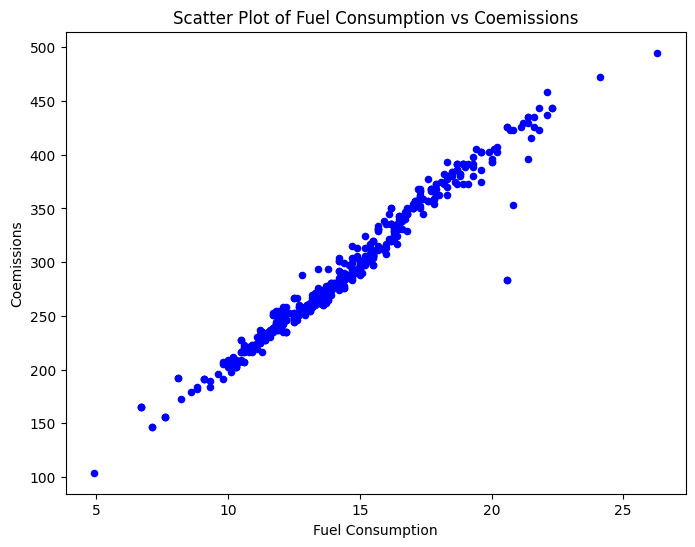

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

dataset.plot(x='FUEL CONSUMPTION', y='COEMISSIONS ', kind='scatter', figsize=(8, 6), color='blue')

# Add title and labels
plt.title('Scatter Plot of Fuel Consumption vs Coemissions')
plt.xlabel('Fuel Consumption')
plt.ylabel('Coemissions')

# Show the plot
plt.show()

Clearly correlates very significantly

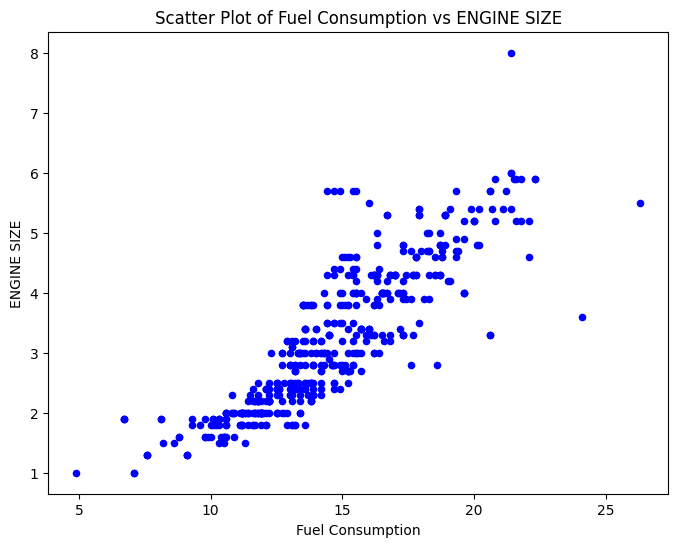

In [12]:
dataset.plot(x='FUEL CONSUMPTION', y='ENGINE SIZE', kind='scatter', figsize=(8, 6), color='blue')

# Add title and labels
plt.title('Scatter Plot of Fuel Consumption vs ENGINE SIZE')
plt.xlabel('Fuel Consumption')
plt.ylabel('ENGINE SIZE')

# Show the plot
plt.show()

ALso has a linearish correlation

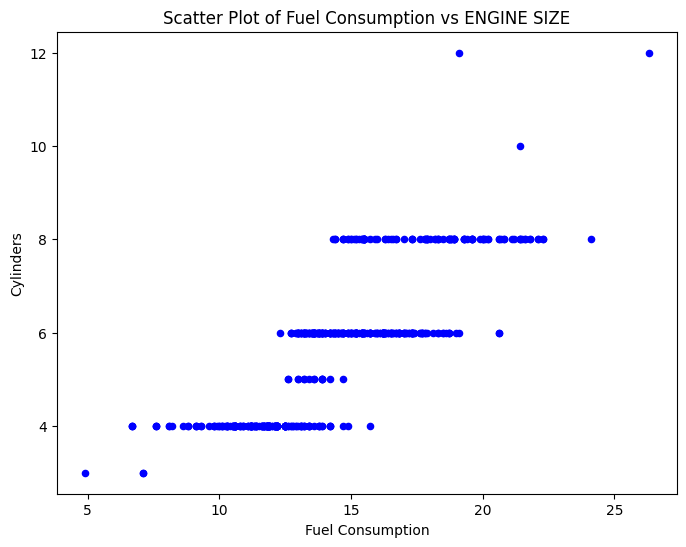

In [13]:
dataset.plot(x='FUEL CONSUMPTION', y='CYLINDERS', kind='scatter', figsize=(8, 6), color='blue')

# Add title and labels
plt.title('Scatter Plot of Fuel Consumption vs ENGINE SIZE')
plt.xlabel('Fuel Consumption')
plt.ylabel('Cylinders')

# Show the plot
plt.show()

This, too scales linearly

In [14]:
print(dataset['VEHICLE CLASS'].value_counts())
print(dataset['TRANSMISSION'].value_counts())
print(dataset['FUEL'].value_counts())
print(dataset['MAKE'].value_counts())

VEHICLE CLASS
COMPACT                     87
SUV                         78
SUBCOMPACT                  76
PICKUP TRUCK - STANDARD     75
MID-SIZE                    64
FULL-SIZE                   23
MINIVAN                     21
STATION WAGON - MID-SIZE    20
VAN - CARGO                 17
VAN - PASSENGER             13
STATION WAGON - SMALL       11
PICKUP TRUCK - SMALL        10
MINICOMPACT                  9
TWO-SEATER                   7
Name: count, dtype: int64
TRANSMISSION
A4     256
M5     158
A5      56
M6      16
AS4     12
A3       9
AS5      4
Name: count, dtype: int64
FUEL
X    372
Z    131
D      5
E      2
N      1
Name: count, dtype: int64
MAKE
CHEVROLET        48
FORD             47
TOYOTA           37
DODGE            37
VOLKSWAGEN       29
GMC              29
BMW              22
PONTIAC          19
AUDI             18
VOLVO            17
CHRYSLER         16
MAZDA            16
NISSAN           16
MERCEDES-BENZ    15
SATURN           14
HONDA            14
SUZUKI   

In [15]:
vclass = pd.read_csv(filepath, usecols=lambda x: x  in ["VEHICLE CLASS", "FUEL CONSUMPTION"])
mean_encoded_vclass = vclass.groupby(["VEHICLE CLASS"])['FUEL CONSUMPTION'].mean().to_dict()

transmission = pd.read_csv(filepath, usecols=lambda x: x  in ["TRANSMISSION", "FUEL CONSUMPTION"])
mean_encoded_transmission = transmission.groupby(['TRANSMISSION'])['FUEL CONSUMPTION'].mean().to_dict()

fuel = pd.read_csv(filepath, usecols=lambda x: x  in ["FUEL", "FUEL CONSUMPTION"])
mean_encoded_fuel = fuel.groupby(['FUEL'])['FUEL CONSUMPTION'].mean().to_dict()

make = pd.read_csv(filepath, usecols=lambda x: x  in ["MAKE", "FUEL CONSUMPTION"])
mean_encoded_make = make.groupby(['MAKE'])['FUEL CONSUMPTION'].mean().to_dict()

In [16]:
dataset['VEHICLE CLASS'] =  dataset['VEHICLE CLASS'].map(mean_encoded_vclass)

dataset['TRANSMISSION'] = dataset['TRANSMISSION'].map(mean_encoded_transmission)
dataset['FUEL'] = dataset['FUEL'].map(mean_encoded_fuel)
dataset['MAKE'] = dataset['MAKE'].map(mean_encoded_make)

In [22]:
print(mean_encoded_vclass)
print(mean_encoded_make)
print(mean_encoded_transmission)
print(mean_encoded_fuel)

{'COMPACT': 12.305747126436781, 'FULL-SIZE': 14.452173913043477, 'MID-SIZE': 13.6828125, 'MINICOMPACT': 14.677777777777777, 'MINIVAN': 15.885714285714286, 'PICKUP TRUCK - SMALL': 14.11, 'PICKUP TRUCK - STANDARD': 17.370666666666665, 'STATION WAGON - MID-SIZE': 13.24, 'STATION WAGON - SMALL': 11.963636363636363, 'SUBCOMPACT': 12.088157894736844, 'SUV': 15.984615384615385, 'TWO-SEATER': 16.928571428571427, 'VAN - CARGO': 18.011764705882353, 'VAN - PASSENGER': 19.323076923076922}
{'ACURA': 12.557142857142859, 'AUDI': 14.36111111111111, 'BMW': 14.795454545454545, 'BUICK': 13.9, 'CADILLAC': 15.233333333333334, 'CHEVROLET': 15.418750000000001, 'CHRYSLER': 13.893749999999999, 'DAEWOO': 11.81111111111111, 'DODGE': 18.762162162162163, 'FERRARI': 25.200000000000003, 'FORD': 15.908510638297873, 'GMC': 17.651724137931033, 'HONDA': 11.214285714285714, 'HYUNDAI': 12.0, 'INFINITI': 13.525, 'ISUZU': 15.642857142857142, 'JAGUAR': 15.814285714285715, 'JEEP': 16.45714285714286, 'KIA': 12.275, 'LAND ROVER

In [23]:
dataset.corr()

,MAKE,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
MAKE,1.000000,0.523843,0.653810,0.620532,0.192649,0.175784,0.722214,0.696936
VEHICLE CLASS,0.523843,1.000000,0.589481,0.442797,0.123403,0.076681,0.684346,0.733708
ENGINE SIZE,0.653810,0.589481,1.000000,0.899827,0.360160,0.118551,0.867575,0.856685
CYLINDERS,0.620532,0.442797,0.899827,1.000000,0.386198,0.152050,0.816789,0.791469
TRANSMISSION,0.192649,0.123403,0.360160,0.386198,1.000000,0.098309,0.354051,0.319435
FUEL,0.175784,0.076681,0.118551,0.152050,0.098309,1.000000,0.275254,0.161357
FUEL CONSUMPTION,0.722214,0.684346,0.867575,0.816789,0.354051,0.275254,1.000000,0.980528
COEMISSIONS,0.696936,0.733708,0.856685,0.791469,0.319435,0.161357,0.980528,1.000000


most of the feature have a decent amount of correlation, but the fuel column does not seem to be proving much information. coemissions, engine size, cylinders, make, and class all correlate reasonably well, in that order.